In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio
import pyarrow.parquet as pq
import json

In [2]:
# Load the parquet file with phoneme segments
parquet_path = "../../data/camstories/audio_embed_full.parquet"
df = pd.read_parquet(parquet_path)

print(f"Loaded {len(df)} tokens")
print("Available tokens:", df['token'].head())


Loaded 29224 tokens
Available tokens: 0      .
1    the
2      ,
3    and
4      a
Name: token, dtype: object


In [3]:
def visualize_token_audio(token_name, df, display_segments=False, sample_rate=24000, tight=True):
    """
    Display and visualize audio for a specific token with phoneme boundaries.
    If display_segments is False, do not show segment boundaries or labels.
    sample_rate: The sample rate to use for audio extraction, playback, and plotting.
    """
    # Find the token in the dataframe
    token_row = df[df['token'] == token_name]
    
    if token_row.empty:
        print(f"Token '{token_name}' not found!")
        return
    
    # Extract audio and segments
    if tight:
        audio_key = f'{sample_rate}_tight'
    else:
        audio_key = f'{sample_rate}_audio'
    if audio_key not in token_row.columns:
        print(f"Sample rate {sample_rate} not found for token '{token_name}'!")
        return
    audio = np.array(token_row.iloc[0][audio_key])
    segments = json.loads(token_row.iloc[0]['segments_json'])

    # Get start and end from the segment json (use min start and max end in case of multiple segments)
    if len(segments) == 0:
        print(f"No segments found for token '{token_name}'!")
        return
    start_ts = min(seg['start'] for seg in segments)
    end_ts = max(seg['end'] for seg in segments)
    
    print(f"Token: '{token_name}'")
    print(f"Audio length: {len(audio)} samples ({len(audio)/sample_rate:.3f}s)")
    print(f"Word timestamps: {start_ts:.3f}s - {end_ts:.3f}s")
    if display_segments:
        print(f"Segments: {segments}")
    
    # Display audio player
    display(Audio(data=audio, rate=sample_rate, autoplay=False))
    
    # Create time axis
    time_axis = np.linspace(0, len(audio)/sample_rate, len(audio))
    
    # Plot waveform
    plt.figure(figsize=(14, 8))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, audio, 'b-', linewidth=0.8)
    
    if display_segments:
        # Add phoneme boundaries and labels
        colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
        for i, seg in enumerate(segments):
            seg_start, seg_end = seg['start'], seg['end']
            phonemes = seg['phonemes']
            text = seg['text']
            
            # Vertical lines for boundaries
            plt.axvline(x=seg_start, color=colors[i], linestyle='-', linewidth=2, alpha=0.7)
            plt.axvline(x=seg_end, color=colors[i], linestyle='-', linewidth=2, alpha=0.7)
            
            # Text label in the middle
            mid_time = (seg_start + seg_end) / 2
            max_amp = np.max(np.abs(audio))
            plt.text(mid_time, max_amp * 0.8, f"{text}\n/{phonemes}/", 
                    ha='center', va='center', fontsize=10, 
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[i], alpha=0.7))
        plt.title(f"Waveform for token: '{token_name}' with phoneme boundaries")
    else:
        plt.title(f"Waveform for token: '{token_name}'")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    # Plot spectrogram
    plt.subplot(2, 1, 2)
    plt.specgram(audio, Fs=sample_rate, NFFT=512, noverlap=256, cmap='magma')
    
    if display_segments:
        # Add phoneme boundaries to spectrogram
        for i, seg in enumerate(segments):
            seg_start, seg_end = seg['start'], seg['end']
            phonemes = seg['phonemes']
            text = seg['text']
            
            plt.axvline(x=seg_start, color='white', linestyle='-', linewidth=2, alpha=0.8)
            plt.axvline(x=seg_end, color='white', linestyle='-', linewidth=2, alpha=0.8)
            
            # Text label in the middle
            mid_time = (seg_start + seg_end) / 2
            # Place text at 1/3 of Nyquist frequency for visibility
            plt.text(mid_time, sample_rate // 3, f"{text}", ha='center', va='center', 
                    fontsize=9, color='white', weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.6))
        plt.title(f"Spectrogram for token: '{token_name}' with phoneme boundaries")
    else:
        plt.title(f"Spectrogram for token: '{token_name}'")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    plt.colorbar(label='Power (dB)')
    
    plt.tight_layout()
    plt.show()

In [4]:
# # Visualize all tokens in the sample dataset
# for token in df['token'].tolist():
#     print(f"\n{'='*50}")
#     visualize_token_audio(token, df)


In [5]:
vocab_size = 10000
vocab_file = f"../../data/camstories/camstories_{vocab_size}_vocab.parquet"

vocab_df = pd.read_parquet(vocab_file)

In [6]:
# get longest token in camstories_10000.parquet

# get the longest token (most characters)
longest_token = vocab_df["token"].iloc[vocab_df["token"].str.len().idxmax()]
# shortest token that is not punctuation
shortest_token = vocab_df[~vocab_df["token"].str.contains(r'[^\w\s]')]["token"].iloc[vocab_df[~vocab_df["token"].str.contains(r'[^\w\s]')]["token"].str.len().idxmin()]
print(longest_token)
print(shortest_token)

misunderstandings
he


Token: 'antidisestablishmentarianism'
Audio length: 24443 samples (1.018s)
Word timestamps: 0.050s - 1.250s


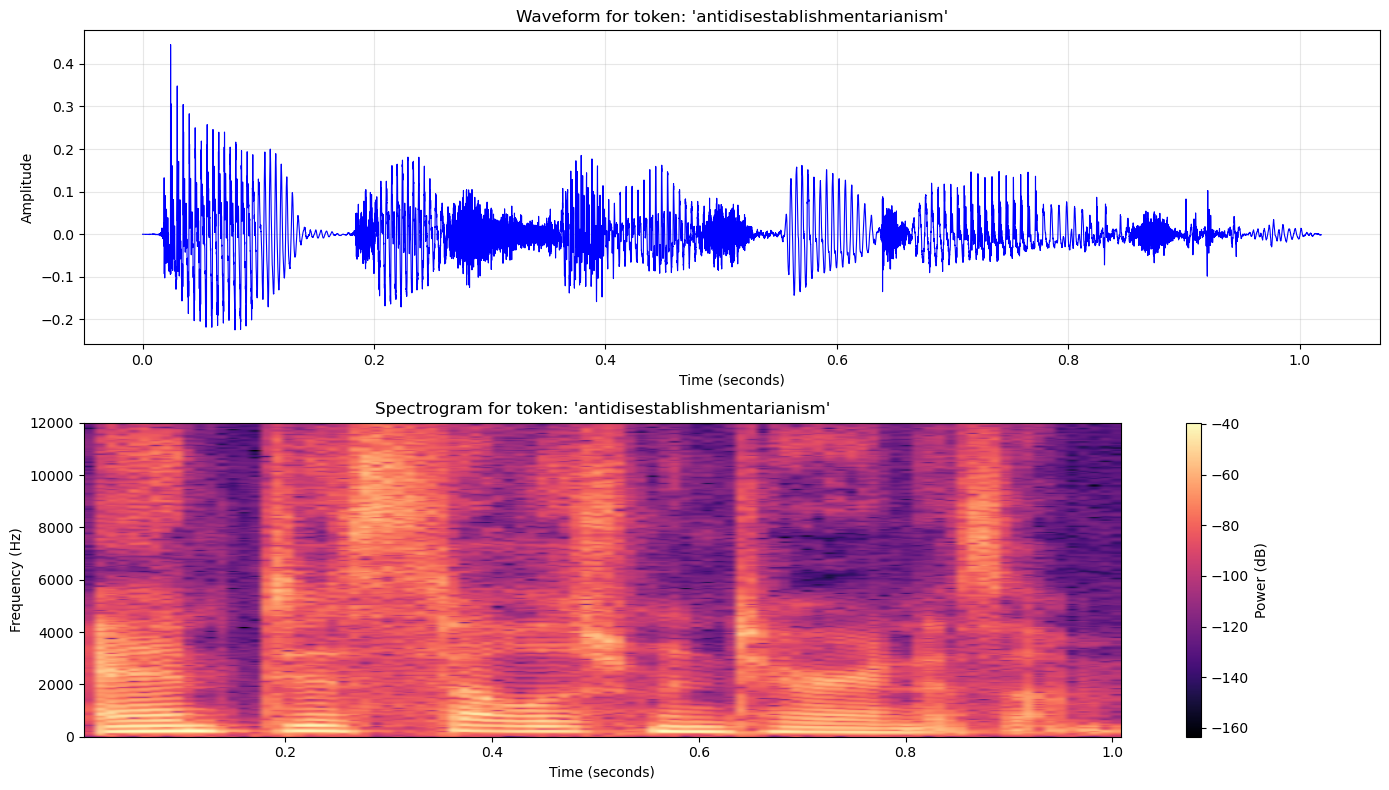

In [7]:
# Longest token in full vocab
# Interactive token selection
token_to_visualize = "antidisestablishmentarianism"  # Change this to any token you want to see
visualize_token_audio(token_to_visualize, df)


Token: 'misunderstandings'
Audio length: 5298 samples (0.662s)
Word timestamps: 0.050s - 0.825s


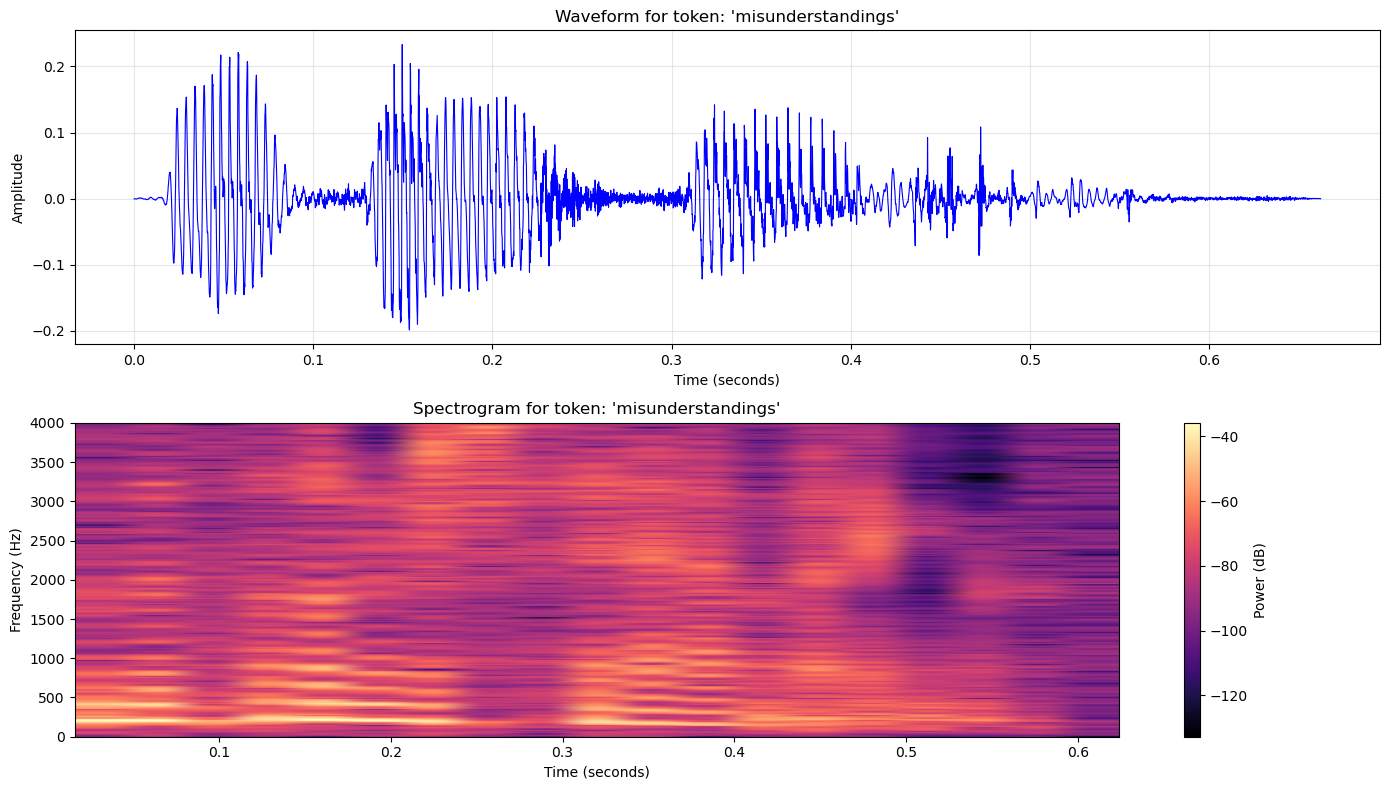

In [8]:
# Longest token in full vocab
# Interactive token selection
visualize_token_audio(longest_token, df, sample_rate=8000, tight=True)


Token: 'he'
Audio length: 1522 samples (0.190s)
Word timestamps: 0.050s - 0.225s


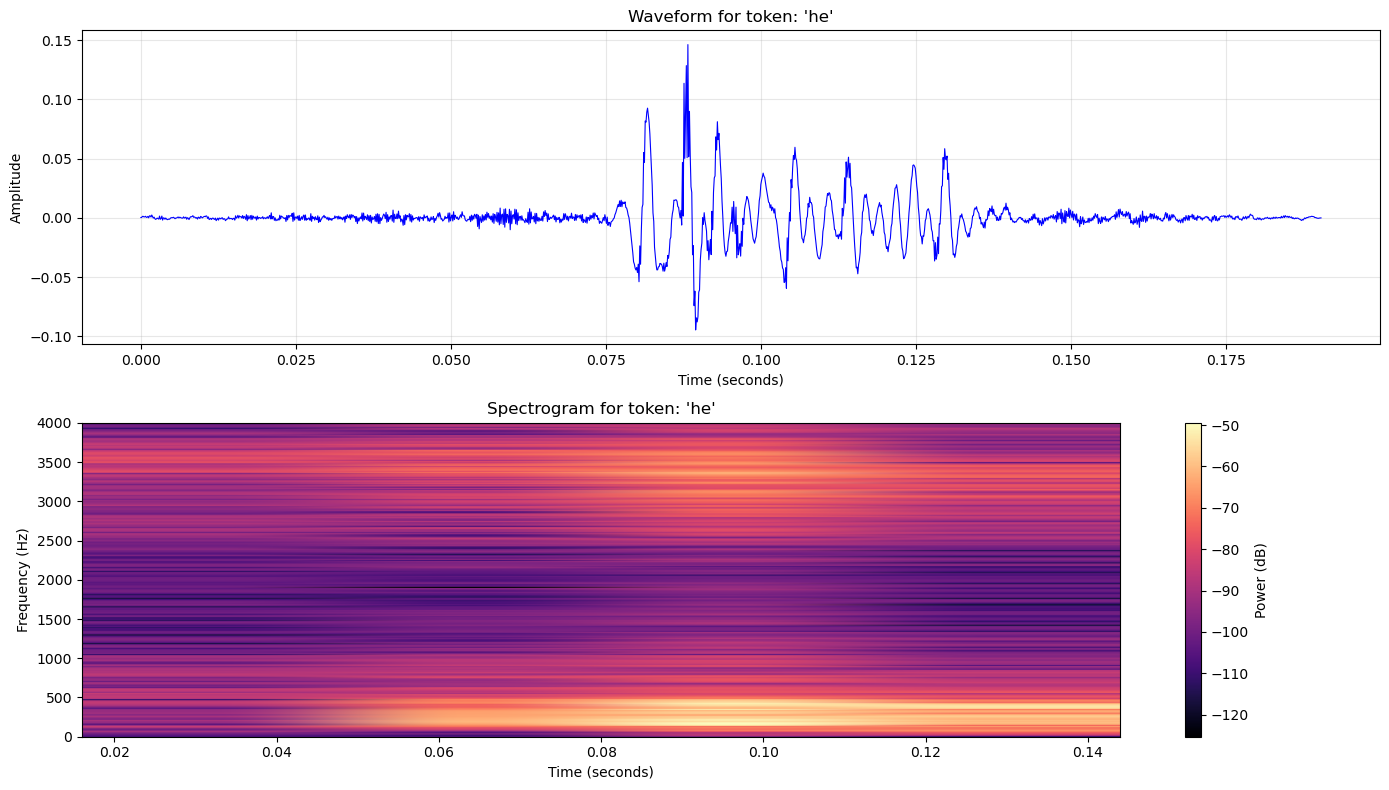

In [11]:
visualize_token_audio(shortest_token, df, sample_rate=8000, tight=True)

Comparing token 'antidisestablishmentarianism' at different sample rates:
Original: 24443 samples at 24000 Hz (1.018s)
  12000 Hz: 12221 samples (1.018s)
Audio preview at 12000 Hz:


  8000 Hz: 8147 samples (1.018s)
Audio preview at 8000 Hz:


  6000 Hz: 6110 samples (1.018s)
Audio preview at 6000 Hz:


  4000 Hz: 4073 samples (1.018s)
Audio preview at 4000 Hz:


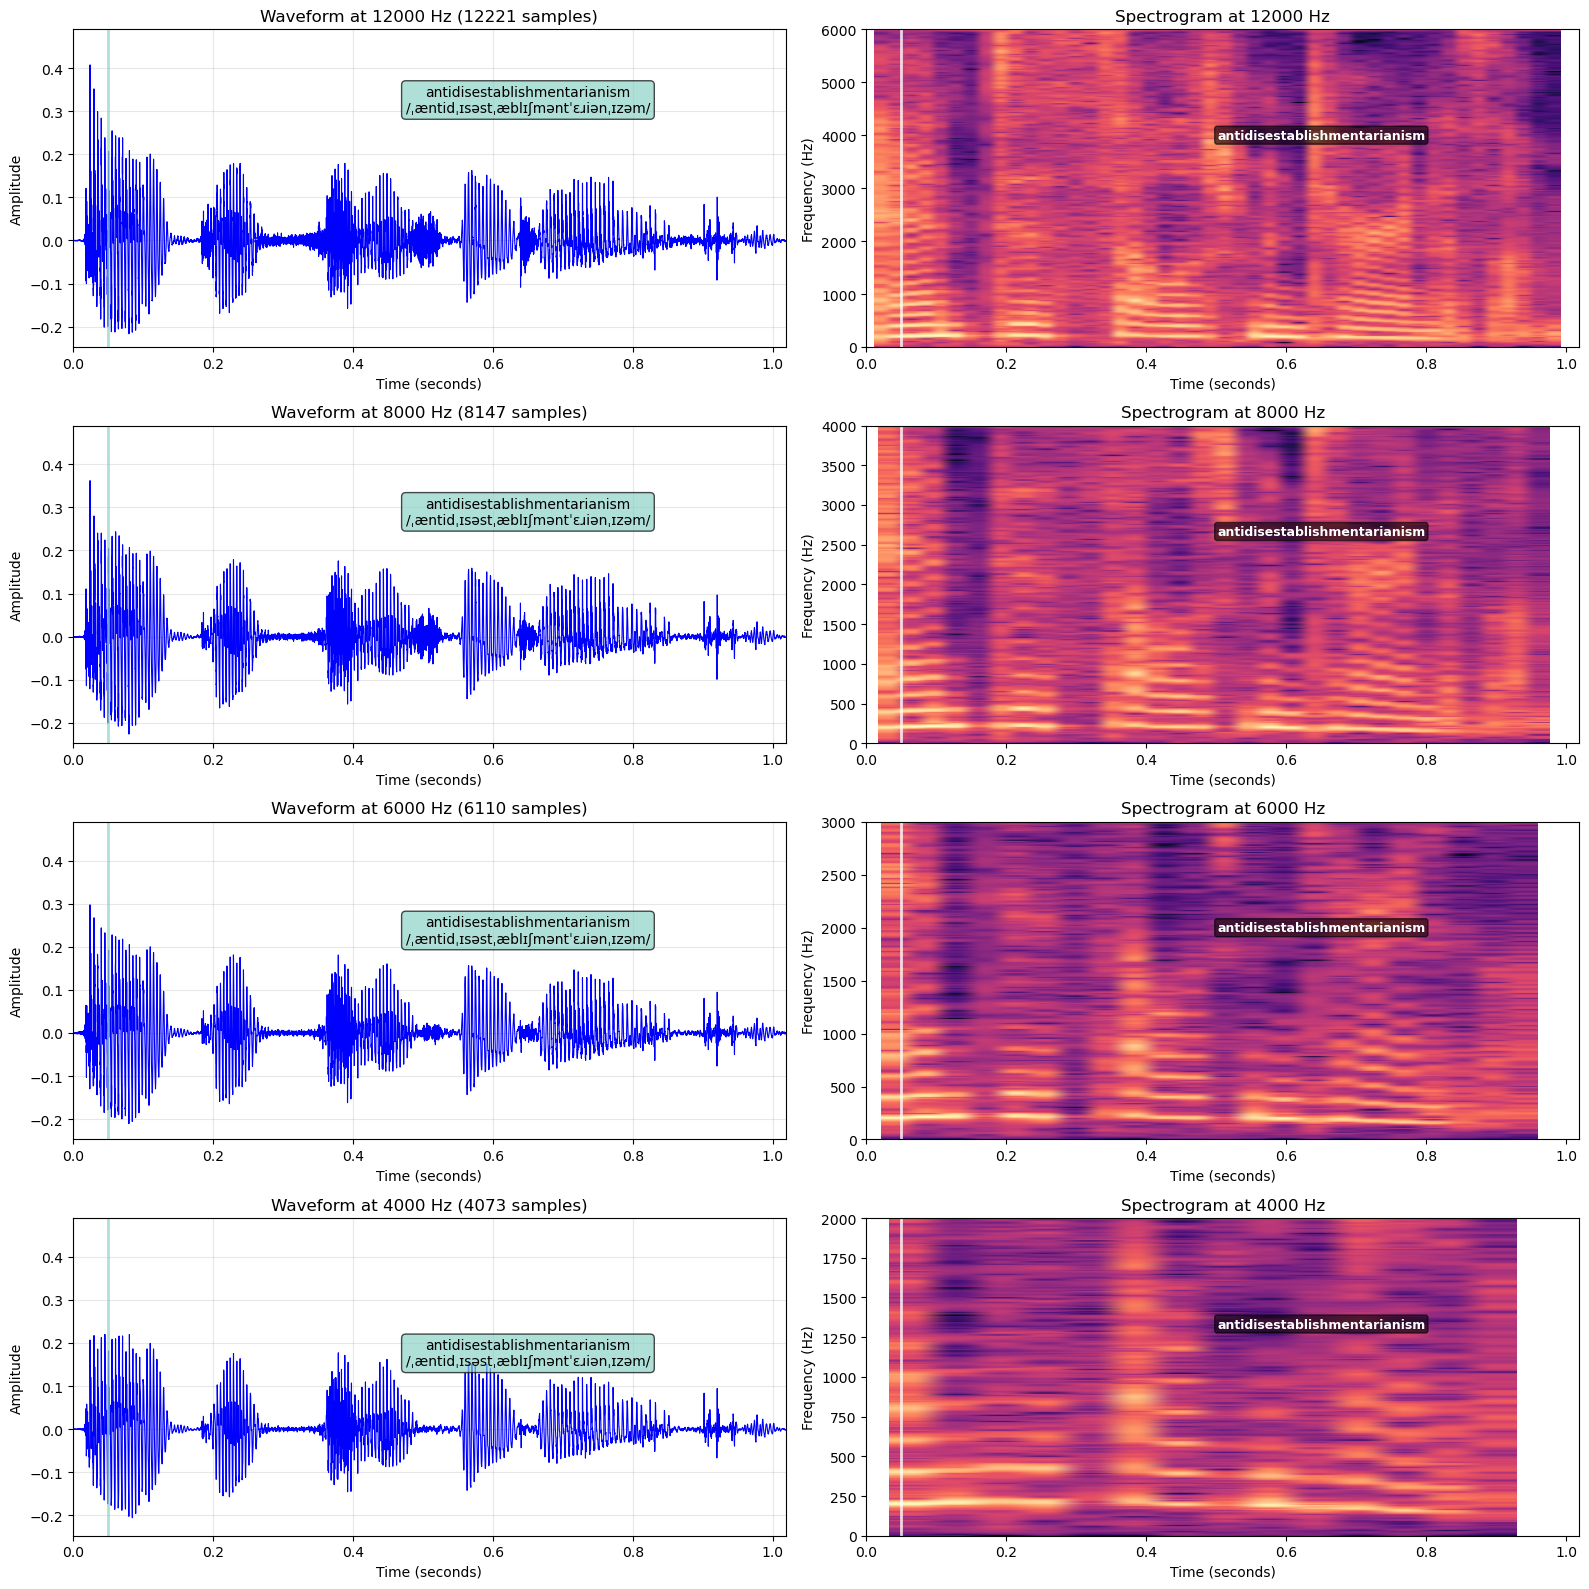

In [10]:
# Visualize the same token at different sample rates
import scipy.signal

def visualize_token_at_different_sample_rates(token_name, df, sample_rates=[12000, 8000, 6000, 4000]):
    """
    Visualize the same token at different sample rates with consistent axis scaling
    """
    # Find the token in the dataframe
    token_row = df[df['token'] == token_name]
    
    if token_row.empty:
        print(f"Token '{token_name}' not found!")
        return
    
    # Extract original 24000 Hz audio
    original_audio = np.array(token_row.iloc[0]['24000_tight'])
    original_sr = 24000
    
    # Get segments for boundary visualization
    segments = json.loads(token_row.iloc[0]['segments_json'])
    
    print(f"Comparing token '{token_name}' at different sample rates:")
    print(f"Original: {len(original_audio)} samples at {original_sr} Hz ({len(original_audio)/original_sr:.3f}s)")
    
    # Calculate axis limits from original audio for consistency
    original_time_axis = np.linspace(0, len(original_audio)/original_sr, len(original_audio))
    time_limit = [0, len(original_audio)/original_sr]
    amp_limit = [np.min(original_audio) * 1.1, np.max(original_audio) * 1.1]
    
    # Create subplots for each sample rate
    fig, axes = plt.subplots(len(sample_rates), 2, figsize=(16, 4*len(sample_rates)))
    
    for i, target_sr in enumerate(sample_rates):
        # Resample audio
        num_samples = int(len(original_audio) * target_sr / original_sr)
        resampled_audio = scipy.signal.resample(original_audio, num_samples)
        
        # Create time axis for resampled audio
        time_axis = np.linspace(0, len(resampled_audio)/target_sr, len(resampled_audio))
        
        print(f"  {target_sr} Hz: {len(resampled_audio)} samples ({len(resampled_audio)/target_sr:.3f}s)")
        
        # Display audio player for this sample rate
        print(f"Audio preview at {target_sr} Hz:")
        display(Audio(data=resampled_audio, rate=target_sr, autoplay=False))
        
        # Plot waveform
        axes[i, 0].plot(time_axis, resampled_audio, 'b-', linewidth=0.8)
        
        # Add phoneme boundaries
        colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
        for j, seg in enumerate(segments):
            seg_start, seg_end = seg['start'], seg['end']
            text = seg['text']
            phonemes = seg['phonemes']
            
            axes[i, 0].axvline(x=seg_start, color=colors[j], linestyle='-', linewidth=2, alpha=0.7)
            axes[i, 0].axvline(x=seg_end, color=colors[j], linestyle='-', linewidth=2, alpha=0.7)
            
            # Text label
            mid_time = (seg_start + seg_end) / 2
            max_amp = np.max(np.abs(resampled_audio))
            axes[i, 0].text(mid_time, max_amp * 0.8, f"{text}\n/{phonemes}/", 
                           ha='center', va='center', fontsize=10, 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[j], alpha=0.7))
        
        # Set consistent axis limits
        axes[i, 0].set_xlim(time_limit)
        axes[i, 0].set_ylim(amp_limit)
        axes[i, 0].set_title(f"Waveform at {target_sr} Hz ({len(resampled_audio)} samples)")
        axes[i, 0].set_xlabel('Time (seconds)')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].grid(True, alpha=0.3)
        
        # Plot spectrogram
        axes[i, 1].specgram(resampled_audio, Fs=target_sr, NFFT=min(512, len(resampled_audio)//4), 
                           noverlap=min(256, len(resampled_audio)//8), cmap='magma')
        
        # Add phoneme boundaries to spectrogram
        for j, seg in enumerate(segments):
            seg_start, seg_end = seg['start'], seg['end']
            text = seg['text']
            
            axes[i, 1].axvline(x=seg_start, color='white', linestyle='-', linewidth=2, alpha=0.8)
            axes[i, 1].axvline(x=seg_end, color='white', linestyle='-', linewidth=2, alpha=0.8)
            
            mid_time = (seg_start + seg_end) / 2
            axes[i, 1].text(mid_time, target_sr//3, f"{text}", ha='center', va='center', 
                           fontsize=9, color='white', weight='bold',
                           bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.6))
        
        # Set consistent time axis for spectrogram
        axes[i, 1].set_xlim(time_limit)
        axes[i, 1].set_title(f"Spectrogram at {target_sr} Hz")
        axes[i, 1].set_xlabel('Time (seconds)')
        axes[i, 1].set_ylabel('Frequency (Hz)')
    
    plt.tight_layout()
    plt.show()

# Visualize the current token at different sample rates
visualize_token_at_different_sample_rates(token_to_visualize, df)
